# Importing libraries

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
PROJECT_DIR = Path(os.environ.get("PROJECT_DIR", "/rs1/researchers/a/amallav/")).resolve()
OUTPUTS_DIR=Path(os.environ.get("OUTPUTS_DIR", "/rs1/researchers/a/amallav/results")).resolve()

# OUTPUTS_CP_DIR = Path(os.environ.get("OUTPUTS_CP_DIR", OUTPUTS_DIR / "outputs_crop")).resolve()

OUTPUTS_BCCP_DIR = Path(os.environ.get("OUTPUTS_BCCP_DIR", OUTPUTS_DIR / "outputs_bioclip_crop")).resolve()
# OUTPUTS_BCCP_DIR.mkdir(parents=True, exist_ok=True)

# CROP_OUT = PROJECT_DIR / "outputs_crop"
# META_CSV = OUTPUTS_CP_DIR / "cropped_metadata.csv" #This is the metadata file that tells us what crop files exist.
OUT_CSV = OUTPUTS_BCCP_DIR / "results_crop_updated.csv"
# output_csv = OUTPUTS_BCCP_DIR / "predictions.csv"

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUTS_DIR:", OUTPUTS_DIR, "| exists:", OUTPUTS_DIR.exists())
# print("OUTPUTS_CP_DIR:", OUTPUTS_CP_DIR, "| exists:", OUTPUTS_CP_DIR.exists())
print("OUTPUTS_BCCP_DIR:", OUTPUTS_BCCP_DIR, "| exists:", OUTPUTS_BCCP_DIR.exists())
# print("META_CSV    :", META_CSV, "| exists:", META_CSV.exists())
print("OUT_CSV     :", OUT_CSV, "| exists:", OUT_CSV.exists())
# print("output_csv     :", output_csv, "| exists:", output_csv.exists())

PROJECT_DIR: /rs1/researchers/a/amallav
OUTPUTS_DIR: /rs1/researchers/a/amallav/results | exists: True
OUTPUTS_BCCP_DIR: /rs1/researchers/a/amallav/results/outputs_bioclip_crop | exists: True
OUT_CSV     : /rs1/researchers/a/amallav/results/outputs_bioclip_crop/results_crop_updated.csv | exists: True


# LOAD FILE

In [3]:
# file_path = "results_crop.csv"

df = pd.read_csv(OUT_CSV)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (373730, 25)
Columns: ['crop_file', 'crop_file_path', 'image_id', 'Falsely identified', 'box_num', 'species', 'User_classified', 'same_species?', 'My analysis', 'common_name', 'kingdom', 'user_kingdom', 'phylum', 'user_phylum', 'class', 'user_class', 'order', 'user_order', 'family', 'user_family', 'genus', 'user_genus', 'score', 'top_no', 'topk_predictions_json']


# HELPER FUNCTIONS

In [61]:
def normalize_text(x):
    """
    Normalize text for comparison:
    - handle NaN
    - convert to string
    - strip spaces
    - lowercase
    - collapse repeated spaces
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = " ".join(x.split())
    if x in ["", "nan", "none", "null"]:
        return np.nan
    return x

In [62]:
# def normalize_bool_false(series):
#     """
#     Robust handling in case same_species? is boolean or string.
#     Returns True for rows where same_species is False.
#     """
#     s = series.astype(str).str.strip().str.lower()
#     return s.isin(["false", "0", "no"])

In [63]:
def normalize_bool_true(series):
    """
    Robust handling in case same_species? is boolean or string.
    Returns True for rows where same_species is True.
    """
    s = series.astype(str).str.strip().str.lower()
    return s.isin(["true", "1", "yes"])

# KEEP ONLY same_species == False

In [64]:
true_df = df[normalize_bool_true(df["same_species?"])].copy()

print("\nRows with same_species == True:", len(true_df))
print("Unique image_ids in true set:", true_df["image_id"].nunique())


Rows with same_species == True: 39177
Unique image_ids in true set: 17840


In [65]:
false_df = df[~df["image_id"].isin(true_df["image_id"])].copy()
print("\nRows with same_species == False:", len(false_df))
print("Unique image_ids in false set:", false_df["image_id"].nunique())


Rows with same_species == False: 103945
Unique image_ids in false set: 6963


# DEFINE TAXONOMIC LEVEL PAIRS

In [66]:
level_pairs = {
    "kingdom": ("kingdom", "user_kingdom"),
    "phylum": ("phylum", "user_phylum"),
    "class": ("class", "user_class"),
    "order": ("order", "user_order"),
    "family": ("family", "user_family"),
    "genus": ("genus", "user_genus"),
    "species": ("species", "User_classified"),
}

In [67]:
# Check required columns exist
missing_cols = []
for level, (pred_col, user_col) in level_pairs.items():
    if pred_col not in false_df.columns:
        missing_cols.append(pred_col)
    if user_col not in false_df.columns:
        missing_cols.append(user_col)

if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(set(missing_cols))}")

In [68]:
# Check required columns exist
missing_cols = []
for level, (pred_col, user_col) in level_pairs.items():
    if pred_col not in df.columns:
        missing_cols.append(pred_col)
    if user_col not in df.columns:
        missing_cols.append(user_col)

if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(set(missing_cols))}")

# NORMALIZE VALUES + CREATE ROW-LEVEL MATCH COLUMNS

In [69]:
for level, (pred_col, user_col) in level_pairs.items():
    false_df[f"{level}_pred_norm"] = false_df[pred_col].apply(normalize_text)
    false_df[f"{level}_user_norm"] = false_df[user_col].apply(normalize_text)

    # row-level exact match only if both are present
    false_df[f"{level}_row_match"] = (
        false_df[f"{level}_pred_norm"].notna()
        & false_df[f"{level}_user_norm"].notna()
        & (false_df[f"{level}_pred_norm"] == false_df[f"{level}_user_norm"])
    )

In [70]:
for level, (pred_col, user_col) in level_pairs.items():
    df[f"{level}_pred_norm"] = df[pred_col].apply(normalize_text)
    df[f"{level}_user_norm"] = df[user_col].apply(normalize_text)

    # row-level exact match only if both are present
    df[f"{level}_row_match"] = (
        df[f"{level}_pred_norm"].notna()
        & df[f"{level}_user_norm"].notna()
        & (df[f"{level}_pred_norm"] == df[f"{level}_user_norm"])
    )

# If one of the rows for an image_id matches, count image as matched

In [71]:
agg_dict = {}
for level in level_pairs.keys():
    agg_dict[f"{level}_row_match"] = "max"   # True if any row matches

image_level = false_df.groupby("image_id", as_index=False).agg(agg_dict)

# Rename columns for readability
image_level = image_level.rename(
    columns={f"{level}_row_match": f"{level}_image_match" for level in level_pairs.keys()}
)

print("\nImage-level match table:")
print(image_level.head())


Image-level match table:
                        image_id  kingdom_image_match  phylum_image_match  \
0  obs_100052837_photo_166933111                 True                True   
1  obs_100052837_photo_166933119                 True                True   
2  obs_100052837_photo_166933123                 True                True   
3  obs_100053359_photo_166934121                 True                True   
4  obs_100053359_photo_166934128                 True                True   

   class_image_match  order_image_match  family_image_match  \
0               True               True               False   
1               True               True                True   
2               True               True               False   
3               True               True                True   
4               True               True                True   

   genus_image_match  species_image_match  
0              False                False  
1              False                False  


In [72]:
agg_dict = {}
for level in level_pairs.keys():
    agg_dict[f"{level}_row_match"] = "max"   # True if any row matches

image_whole_level = df.groupby("image_id", as_index=False).agg(agg_dict)

# Rename columns for readability
image_whole_level = image_whole_level.rename(
    columns={f"{level}_row_match": f"{level}_image_match" for level in level_pairs.keys()}
)

print("\nImage-level match table:")
print(image_whole_level)


Image-level match table:
                            image_id  kingdom_image_match  phylum_image_match  \
0       obs_10003229_photo_114145431                 True                True   
1      obs_100052837_photo_166933111                 True                True   
2      obs_100052837_photo_166933119                 True                True   
3      obs_100052837_photo_166933123                 True                True   
4      obs_100053359_photo_166934121                 True                True   
...                              ...                  ...                 ...   
24798   obs_99990955_photo_166796310                 True                True   
24799   obs_99990955_photo_166796399                 True                True   
24800   obs_99990955_photo_166796459                 True                True   
24801   obs_99990956_photo_166796339                 True                True   
24802   obs_99990956_photo_166796345                 True                True   

 

# ACCURACY BY TAXONOMIC LEVEL

In [73]:
accuracy_rows = []
n_images = len(image_level)

for level in level_pairs.keys():
    if level == "species": continue  # Skip species level for accuracy calculation
    match_col = f"{level}_image_match"
    matched_images = image_level[match_col].sum()
    accuracy = matched_images / n_images if n_images > 0 else np.nan

    accuracy_rows.append({
        "Level": level,
        "Matched_image_ids": int(matched_images),
        "Total_image_ids": int(n_images),
        "Accuracy": accuracy,
        "Accuracy_%": round(accuracy * 100, 2) if pd.notna(accuracy) else np.nan
    })

accuracy_df = pd.DataFrame(accuracy_rows)


print("\n=== Accuracy by Taxonomic Level (Image-level) ===")
print(accuracy_df.sort_values("Accuracy", ascending=False))



=== Accuracy by Taxonomic Level (Image-level) ===
     Level  Matched_image_ids  Total_image_ids  Accuracy  Accuracy_%
0  kingdom               6512             6963  0.935229       93.52
1   phylum               6258             6963  0.898751       89.88
2    class               5022             6963  0.721241       72.12
3    order               4206             6963  0.604050       60.40
4   family               3952             6963  0.567571       56.76
5    genus               2329             6963  0.334482       33.45


In [74]:
accuracy_rows = []
n_images = len(image_whole_level)

for level in level_pairs.keys():
    # if level == "species": continue  # Skip species level for accuracy calculation
    match_col = f"{level}_image_match"
    matched_images = image_whole_level[match_col].sum()
    accuracy = matched_images / n_images if n_images > 0 else np.nan

    accuracy_rows.append({
        "Level": level,
        "Matched_image_ids": int(matched_images),
        "Total_image_ids": int(n_images),
        "Accuracy": accuracy,
        "Accuracy_%": round(accuracy * 100, 2) if pd.notna(accuracy) else np.nan
    })

accuracy_whole_df = pd.DataFrame(accuracy_rows)

print("\n=== Accuracy by Taxonomic Level (Image-level) ===")
print(accuracy_whole_df.sort_values("Accuracy", ascending=False))


=== Accuracy by Taxonomic Level (Image-level) ===
     Level  Matched_image_ids  Total_image_ids  Accuracy  Accuracy_%
0  kingdom              24352            24803  0.981817       98.18
1   phylum              24098            24803  0.971576       97.16
2    class              21451            24803  0.864855       86.49
4   family              21420            24803  0.863605       86.36
3    order              20736            24803  0.836028       83.60
5    genus              20167            24803  0.813087       81.31
6  species              17840            24803  0.719268       71.93


In [75]:
# accuracy_df.to_csv("taxonomy_accuracy_by_level.csv", index=False)
# image_level.to_csv("image_level_taxonomy_match.csv", index=False)

# print("\nSaved:")
# print("- taxonomy_accuracy_by_level.csv")
# print("- image_level_taxonomy_match.csv")

# Visualization

## BAR CHART OF ACCURACY BY LEVEL

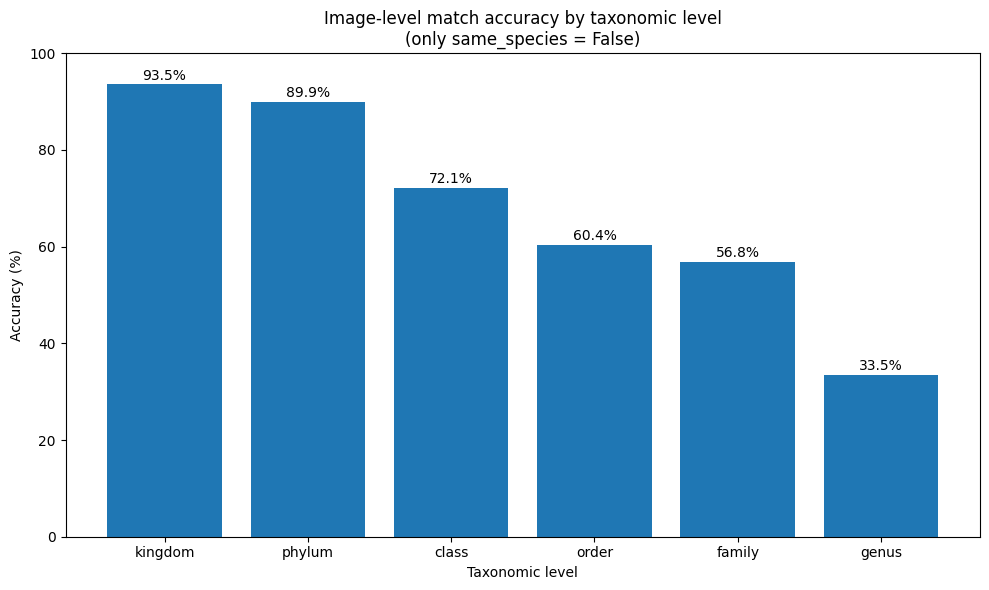

In [76]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_df["Level"], accuracy_df["Accuracy_%"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Taxonomic level")
plt.title("Image-level match accuracy by taxonomic level\n(only same_species = False)")
plt.ylim(0, 100)

for i, v in enumerate(accuracy_df["Accuracy_%"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()


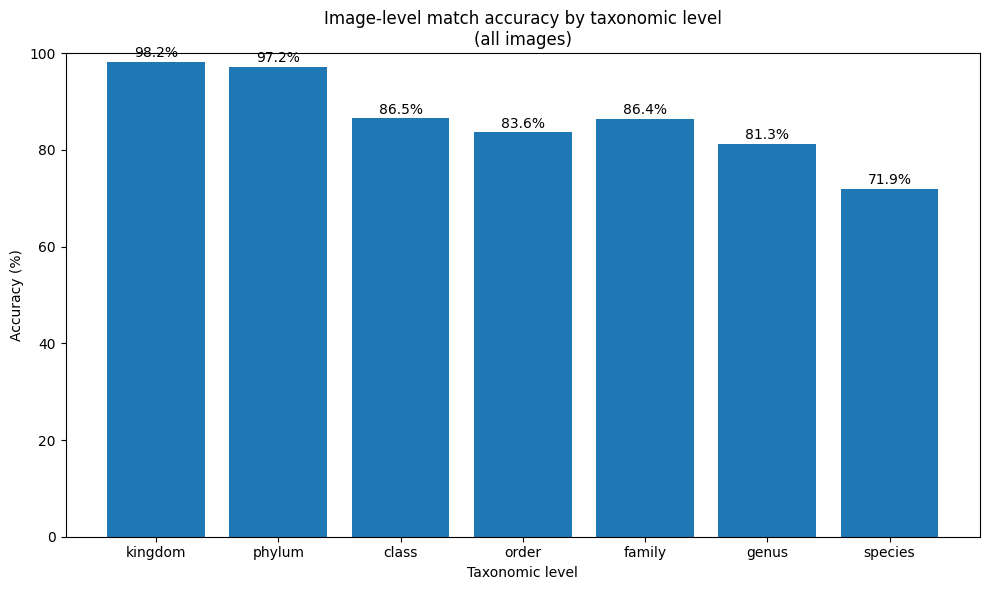

In [77]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_whole_df["Level"], accuracy_whole_df["Accuracy_%"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Taxonomic level")
plt.title("Image-level match accuracy by taxonomic level\n(all images)")
plt.ylim(0, 100)

for i, v in enumerate(accuracy_whole_df["Accuracy_%"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()


## MATCH COUNTS BY LEVEL

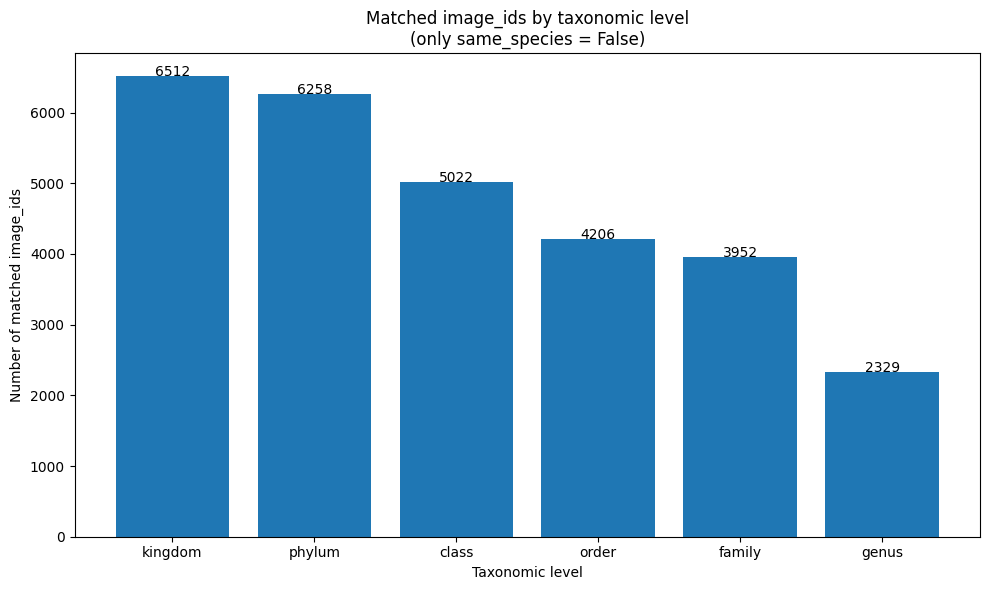

In [78]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_df["Level"], accuracy_df["Matched_image_ids"])
plt.ylabel("Number of matched image_ids")
plt.xlabel("Taxonomic level")
plt.title("Matched image_ids by taxonomic level\n(only same_species = False)")

for i, v in enumerate(accuracy_df["Matched_image_ids"]):
    plt.text(i, v + 0.2, str(v), ha="center")

plt.tight_layout()
plt.show()

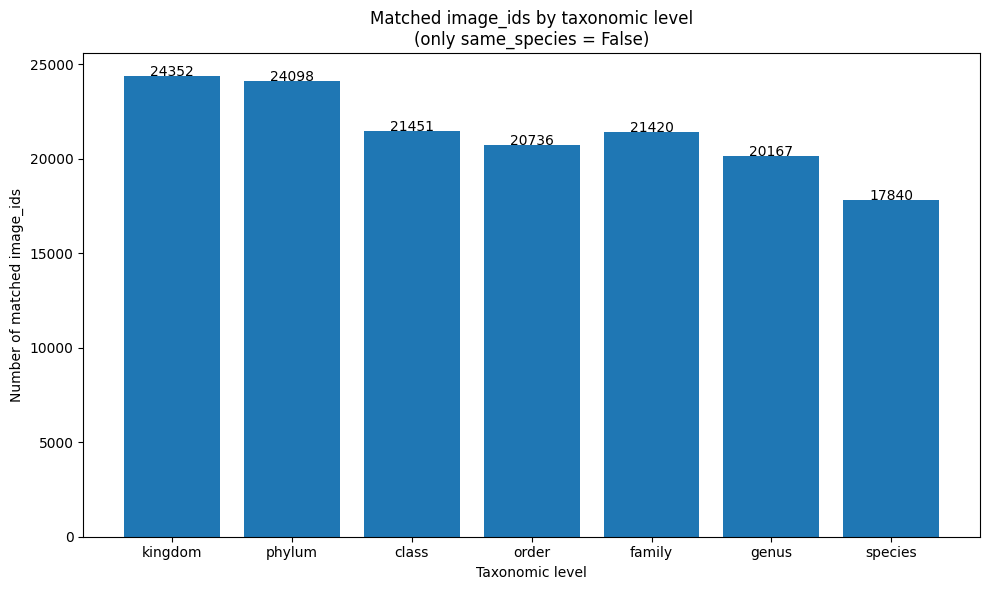

In [79]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_whole_df["Level"], accuracy_whole_df["Matched_image_ids"])
plt.ylabel("Number of matched image_ids")
plt.xlabel("Taxonomic level")
plt.title("Matched image_ids by taxonomic level\n(only same_species = False)")

for i, v in enumerate(accuracy_whole_df["Matched_image_ids"]):
    plt.text(i, v + 0.2, str(v), ha="center")

plt.tight_layout()
plt.show()

## IMAGE-LEVEL MATCH HEATMAP

In [80]:
# heatmap_df = image_level.set_index("image_id").astype(int)

# plt.figure(figsize=(12, max(6, len(heatmap_df) * 0.25)))
# plt.imshow(heatmap_df, aspect="auto")
# plt.colorbar(label="Match (1 = yes, 0 = no)")
# plt.xticks(
#     ticks=range(len(heatmap_df.columns)),
#     labels=[c.replace("_image_match", "") for c in heatmap_df.columns],
#     rotation=45
# )
# plt.yticks(ticks=range(len(heatmap_df.index)), labels=heatmap_df.index)
# plt.title("Image-level taxonomy match heatmap\n(only same_species = False)")
# plt.tight_layout()
# plt.show()

In [81]:
# heatmap_df = image_whole_level.set_index("image_id").astype(int)

# plt.figure(figsize=(12, max(6, len(heatmap_df) * 0.25)))
# plt.imshow(heatmap_df, aspect="auto")
# plt.colorbar(label="Match (1 = yes, 0 = no)")
# plt.xticks(
#     ticks=range(len(heatmap_df.columns)),
#     labels=[c.replace("_image_match", "") for c in heatmap_df.columns],
#     rotation=45
# )
# plt.yticks(ticks=range(len(heatmap_df.index)), labels=heatmap_df.index)
# plt.title("Image-level taxonomy match heatmap\n(only same_species = False)")
# plt.tight_layout()
# plt.show()

# Summary

In [82]:
print("\n=== Summary ===")
best_level = accuracy_df.sort_values("Accuracy", ascending=False).iloc[0]
worst_level = accuracy_df.sort_values("Accuracy", ascending=True).iloc[0]

print(f"Total false-species image_ids analyzed: {n_images}")
print(f"Highest image-level match: {best_level['Level']} ({best_level['Accuracy_%']}%)")
print(f"Lowest image-level match: {worst_level['Level']} ({worst_level['Accuracy_%']}%)")


=== Summary ===
Total false-species image_ids analyzed: 24803
Highest image-level match: kingdom (93.52%)
Lowest image-level match: genus (33.45%)


In [83]:
print("\n=== Summary ===")
best_level = accuracy_whole_df.sort_values("Accuracy", ascending=False).iloc[0]
worst_level = accuracy_whole_df.sort_values("Accuracy", ascending=True).iloc[0]

print(f"Total false-species image_ids analyzed: {n_images}")
print(f"Highest image-level match: {best_level['Level']} ({best_level['Accuracy_%']}%)")
print(f"Lowest image-level match: {worst_level['Level']} ({worst_level['Accuracy_%']}%)")


=== Summary ===
Total false-species image_ids analyzed: 24803
Highest image-level match: kingdom (98.18%)
Lowest image-level match: species (71.93%)


# Analysis type distribution

In [110]:
analysis_df = df[(df["same_species?"]==False) & df["My analysis"].notna()]
len(analysis_df["My analysis"])

430

In [111]:
analysis_df["My analysis"].value_counts()

My analysis
Species features not very clear             110
Species is small part of the box. Fungus    105
Species is small part of the box             94
Misidentified as different species           49
Species not in the box                       40
Same genus but diff species                  32
Name: count, dtype: int64

In [112]:
analysis_df["My analysis"].unique()

<StringArray>
[                  'Species not in the box',
          'Species features not very clear',
         'Species is small part of the box',
       'Misidentified as different species',
 'Species is small part of the box. Fungus',
              'Same genus but diff species']
Length: 6, dtype: str

In [113]:
analysis_df["image_box"]=analysis_df["image_id"] + "_" + analysis_df["box_num"].astype(str)
analysis_df["image_box"].head(10)

25    obs_10317797_photo_14298032_1
26    obs_10317797_photo_14298032_1
27    obs_10317797_photo_14298032_1
28    obs_10317797_photo_14298032_1
29    obs_10317797_photo_14298032_1
30    obs_10317797_photo_14298032_2
31    obs_10317797_photo_14298032_2
32    obs_10317797_photo_14298032_2
33    obs_10317797_photo_14298032_2
34    obs_10317797_photo_14298032_2
Name: image_box, dtype: str

In [114]:
analysis_df["image_box"].unique()

<StringArray>
[  'obs_10317797_photo_14298032_1',   'obs_10317797_photo_14298032_2',
  'obs_130480768_photo_70327211_1',  'obs_130480768_photo_70327211_2',
  'obs_130480768_photo_70327211_3', 'obs_194599339_photo_342107100_1',
 'obs_194599339_photo_342107100_2', 'obs_220102252_photo_389649357_1',
 'obs_220102252_photo_389649357_2', 'obs_220822650_photo_391000325_1',
 'obs_220822650_photo_391000325_2', 'obs_250956763_photo_448935283_1',
 'obs_250956763_photo_448935283_2', 'obs_250956763_photo_448935283_3',
 'obs_250956763_photo_448935283_4', 'obs_250956763_photo_448935283_5',
 'obs_256022699_photo_458927175_1', 'obs_256022699_photo_458927175_2',
 'obs_256022699_photo_458927175_3', 'obs_258568965_photo_463949088_1',
 'obs_258568965_photo_463949088_2', 'obs_258568965_photo_463949088_3',
 'obs_258568965_photo_463949088_4', 'obs_258568965_photo_463949088_5',
 'obs_264953671_photo_475827468_1', 'obs_264953671_photo_475827468_2',
 'obs_302755190_photo_545634287_1', 'obs_302755190_photo_545634

In [115]:
summary_dict={}


for image_box, group_df in analysis_df.groupby("image_box"):
    # print(image_box)
    # print(group_df)
    for i in range(len(group_df)-1):
        if group_df["My analysis"].iloc[i]=="Same genus but diff species":
            summary_dict["Same genus but diff species"]=summary_dict.get("Same genus but diff species",0)+1
        else:
            summary_dict[group_df["My analysis"].iloc[i]]=summary_dict.get(group_df["My analysis"].iloc[i],0)+1
print(summary_dict)


{'Species not in the box': 32, 'Species features not very clear': 88, 'Species is small part of the box': 75, 'Misidentified as different species': 40, 'Species is small part of the box. Fungus': 84, 'Same genus but diff species': 25}


In [116]:
summary_dict={}
    
for _, group_df in analysis_df.groupby("image_box"):
    if group_df["My analysis"].eq("Same genus but diff species").any():
        summary_dict["Same genus but diff species"]=summary_dict.get("Same genus but diff species",0)+1
    else:
        summary_dict[group_df["My analysis"].iloc[i]]=summary_dict.get(group_df["My analysis"].iloc[i],0)+1

print(summary_dict)

{'Species not in the box': 8, 'Species features not very clear': 19, 'Species is small part of the box': 18, 'Misidentified as different species': 5, 'Species is small part of the box. Fungus': 21, 'Same genus but diff species': 15}


In [117]:

df_summary = pd.DataFrame(
    summary_dict.items(),
    columns=["Category", "Count"]
)


In [118]:

total = df_summary["Count"].sum()
print("Total:", total)
df_summary["Percentage"] = (df_summary["Count"] / total) * 100

print(df_summary)


Total: 86
                                   Category  Count  Percentage
0                    Species not in the box      8    9.302326
1           Species features not very clear     19   22.093023
2          Species is small part of the box     18   20.930233
3        Misidentified as different species      5    5.813953
4  Species is small part of the box. Fungus     21   24.418605
5               Same genus but diff species     15   17.441860


In [122]:
group_mapping = {
    "Group 1: Same genus but diff species": [
        "Same genus but diff species"
    ],
    "Group 2: Species is small part of the box": [
        "Species is small part of the box",
        "Species is small part of the box. Fungus."
    ],
    "Group 3: Species features not very clear": [
        "Species features not very clear",
        "Species is small part of the box; Species features not very clear",
        "Species is small part of the box. Fungus; Species features not very clear"
    ],
    "Group 4: Misidentified as different species": [
        "Misidentified as different species"
    ],
    "Group 5: Species not in the box": [
        "Species not in the box"
    ]
}

# -----------------------------
# 3. Compute grouped stats
# -----------------------------
rows = []

for group_name, notes in group_mapping.items():
    count = analysis_df[analysis_df["My analysis"].isin(notes)].shape[0]
    
    rows.append({
        "Group": group_name,
        "Count": count,
        "% of false": round((count / len(false_df)) * 100, 2) if len(false_df) else 0,
        "% of total": round((count / total) * 100, 2) if total else 0
    })

grouped_stats = pd.DataFrame(rows)

print(grouped_stats)

                                         Group  Count  % of false  % of total
0         Group 1: Same genus but diff species     32        7.44       37.21
1    Group 2: Species is small part of the box     94       21.86      109.30
2     Group 3: Species features not very clear    110       25.58      127.91
3  Group 4: Misidentified as different species     49       11.40       56.98
4              Group 5: Species not in the box     40        9.30       46.51


# Which Category was rightly classified?

In [4]:
accuracy_whole_df

NameError: name 'accuracy_whole_df' is not defined

# Which Category was wrongly classified?

In [21]:
match_df = df[df["Falsely identified"] == "Match"]
match_df

,crop_file,crop_file_path,image_id,Falsely identified,box_num,species,User_classified,same_species?,My analysis,common_name,...,user_class,order,user_order,family,user_family,genus,user_genus,score,top_no,topk_predictions_json
0,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Cerocala contraria,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Cerocala,Eudocima,0.178396,1,"[{""species"": ""Cerocala contraria"", ""common_nam..."
1,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Chrysorithrum flavomaculata,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Chrysorithrum,Eudocima,0.134323,2,"[{""species"": ""Cerocala contraria"", ""common_nam..."
2,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Ulotrichopus marmoratus,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Ulotrichopus,Eudocima,0.066452,3,"[{""species"": ""Cerocala contraria"", ""common_nam..."
3,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima divitiosa,Eudocima divitiosa,True,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Eudocima,Eudocima,0.058108,4,"[{""species"": ""Cerocala contraria"", ""common_nam..."
4,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima colubra,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Eudocima,Eudocima,0.032328,5,"[{""species"": ""Cerocala contraria"", ""common_nam..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373590,obs_99944557_photo_166725516_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99944557_photo_166725516,Match,2,Anolis sagrei,Anolis sagrei,True,NaN,Brown anole,...,Reptilia,NaN,Squamata,Dactyloidae,Anolidae,Anolis,Anolis,0.926809,1,"[{""species"": ""Anolis sagrei"", ""common_name"": ""..."
373591,obs_99944557_photo_166725516_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99944557_photo_166725516,Match,2,Anolis carolinensis,Anolis sagrei,False,NaN,Green anole,...,Reptilia,NaN,Squamata,Dactyloidae,Anolidae,Anolis,Anolis,0.009034,2,"[{""species"": ""Anolis sagrei"", ""common_name"": ""..."
373592,obs_99944557_photo_166725516_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99944557_photo_166725516,Match,2,Anolis ustus,Anolis sagrei,False,NaN,NaN,...,Reptilia,NaN,Squamata,Dactyloidae,Anolidae,Anolis,Anolis,0.003760,3,"[{""species"": ""Anolis sagrei"", ""common_name"": ""..."
373593,obs_99944557_photo_166725516_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99944557_photo_166725516,Match,2,Anolis homolechis,Anolis sagrei,False,NaN,Habana anole,...,Reptilia,NaN,Squamata,Dactyloidae,Anolidae,Anolis,Anolis,0.002795,4,"[{""species"": ""Anolis sagrei"", ""common_name"": ""..."


In [22]:
match_phylum = match_df.groupby("phylum", as_index=False)
match_phylum

In [20]:
# match_df.groupby("phylum")

In [26]:
temp=df.copy()
status_col = "Falsely identified"
pred_col = "phylum"
true_col = "user_phylum"
temp

,crop_file,crop_file_path,image_id,Falsely identified,box_num,species,User_classified,same_species?,My analysis,common_name,...,user_class,order,user_order,family,user_family,genus,user_genus,score,top_no,topk_predictions_json
0,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Cerocala contraria,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Cerocala,Eudocima,0.178396,1,"[{""species"": ""Cerocala contraria"", ""common_nam..."
1,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Chrysorithrum flavomaculata,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Chrysorithrum,Eudocima,0.134323,2,"[{""species"": ""Cerocala contraria"", ""common_nam..."
2,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Ulotrichopus marmoratus,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Ulotrichopus,Eudocima,0.066452,3,"[{""species"": ""Cerocala contraria"", ""common_nam..."
3,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima divitiosa,Eudocima divitiosa,True,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Eudocima,Eudocima,0.058108,4,"[{""species"": ""Cerocala contraria"", ""common_nam..."
4,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima colubra,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Eudocima,Eudocima,0.032328,5,"[{""species"": ""Cerocala contraria"", ""common_nam..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373725,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco porphyreolophus,Gallirex porphyreolophus,False,NaN,Purple-crested Turaco,...,Aves,Musophagiformes,Musophagiformes,Musophagidae,Musophagidae,Tauraco,Gallirex,0.921519,1,"[{""species"": ""Tauraco porphyreolophus"", ""commo..."
373726,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco hartlaubi,Gallirex porphyreolophus,False,NaN,Hartlaub's Turaco,...,Aves,Musophagiformes,Musophagiformes,Musophagidae,Musophagidae,Tauraco,Gallirex,0.019476,2,"[{""species"": ""Tauraco porphyreolophus"", ""commo..."
373727,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco erythrolophus,Gallirex porphyreolophus,False,NaN,Red-crested Turaco,...,Aves,Musophagiformes,Musophagiformes,Musophagidae,Musophagidae,Tauraco,Gallirex,0.007151,3,"[{""species"": ""Tauraco porphyreolophus"", ""commo..."
373728,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco fischeri,Gallirex porphyreolophus,False,NaN,Fischer's turaco,...,Aves,Musophagiformes,Musophagiformes,Musophagidae,Musophagidae,Tauraco,Gallirex,0.005640,4,"[{""species"": ""Tauraco porphyreolophus"", ""commo..."


In [27]:
# 2. CLEAN / NORMALIZE
# =========================
def clean_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "":
        return np.nan
    return x

df[status_col] = df[status_col].apply(clean_text)
df[pred_col] = df[pred_col].apply(clean_text)
df[true_col] = df[true_col].apply(clean_text)


In [28]:
# keep only rows where status is one of the two expected values
valid_status = ["Match", "No Match"]
temp = df[df[status_col].isin(valid_status)].copy()

In [29]:
temp["is_match"] = temp[status_col].eq("Match")

In [31]:
print("Total valid rows:", len(temp))
print("Unique actual user phylum:", temp[true_col].nunique())
print("Unique actual user phylum:", temp[pred_col].nunique())

Total valid rows: 373730
Unique actual user phylum: 18
Unique actual user phylum: 51


## GROUPED STATS BY PHYLUM

In [47]:
phylum_stats = (
    temp.groupby(pred_col)[status_col]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

In [48]:
phylum_stats

Falsely identified,phylum,Match,No Match
0,Acanthocephala,22,15
1,Actinobacteriota,6,9
2,Annelida,493,271
3,Anthocerotophyta,5,0
4,Arthropoda,110120,44995
5,Ascomycota,4616,3927
6,Basidiomycota,2038,1666
7,Blastocladiomycota,2,15
8,Brachiopoda,10,7
9,Bryophyta,14,9


In [49]:
# make sure both columns exist
if "Match" not in phylum_stats.columns:
    phylum_stats["Match"] = 0
if "No Match" not in phylum_stats.columns:
    phylum_stats["No Match"] = 0

In [50]:
phylum_stats = phylum_stats.rename(columns={
    true_col: "user_phylum",
    "Match": "count_match",
    "No Match": "count_no_match"
})

In [51]:
phylum_stats["total_in_category"] = phylum_stats["count_match"] + phylum_stats["count_no_match"]
phylum_stats["percentage_success"] = (phylum_stats["count_match"] / phylum_stats["total_in_category"] * 100).round(2)
phylum_stats["percentage_not_success"] = (phylum_stats["count_no_match"] / phylum_stats["total_in_category"] * 100).round(2)


In [52]:
phylum_stats = phylum_stats.sort_values(
    ["count_no_match", "percentage_not_success", "total_in_category"],
    ascending=[False, False, False]
).reset_index(drop=True)


In [53]:
print("\n=== Distribution by actual phylum (user_phylum) ===")
print(phylum_stats)


=== Distribution by actual phylum (user_phylum) ===
Falsely identified               phylum  count_match  count_no_match  \
0                            Arthropoda       110120           44995   
1                              Chordata       101232           33499   
2                          Tracheophyta        45112           16361   
3                            Ascomycota         4616            3927   
4                         Basidiomycota         2038            1666   
5                              Mollusca         3065            1563   
6                              Annelida          493             271   
7                       Platyhelminthes          279             227   
8                         Echinodermata          677             225   
9                        Proteobacteria          158             202   
10                             Cnidaria          296             164   
11                          Onychophora          378             128   
12         

In [56]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Clean relevant columns
# -----------------------------
# change these names if needed
model_col = "phylum"
user_col = "user_phylum"
result_col = "Falsely identified"

# make a copy
temp = df[[model_col, user_col, result_col]].copy()

# normalize text
for col in [model_col, user_col, result_col]:
    temp[col] = temp[col].astype(str).str.strip()

# optional: standardize case for result column
temp[result_col] = temp[result_col].str.lower()

# keep only valid rows
temp = temp[temp[result_col].isin(["match", "no match"])].copy()

# -----------------------------
# 2. Count Match / No Match by model phylum
# -----------------------------
summary = (
    temp.groupby(model_col)[result_col]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

# make sure both columns exist even if one is absent in data
if "match" not in summary.columns:
    summary["match"] = 0
if "no match" not in summary.columns:
    summary["no match"] = 0

summary["total"] = summary["match"] + summary["no match"]
summary["% success"] = (summary["match"] / summary["total"] * 100).round(2)
summary["% not success"] = (summary["no match"] / summary["total"] * 100).round(2)

# -----------------------------
# 3. Add most common user_phylum for each model phylum
# -----------------------------
most_common_user = (
    temp.groupby(model_col)[user_col]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
    .rename(columns={user_col: "most_common_user_phylum"})
)

summary = summary.merge(most_common_user, on=model_col, how="left")

# reorder columns
summary = summary[
    [
        model_col,
        "most_common_user_phylum",
        "match",
        "no match",
        "total",
        "% success",
        "% not success",
    ]
].sort_values(by="total", ascending=False)

print("=== Statistics by model phylum ===")
print(summary)

# -----------------------------
# 4. Questions
# -----------------------------

# wrongly classified the most (highest No Match count)
most_wrong = summary.sort_values(by="no match", ascending=False).head(1)

# rightly classified the most (highest Match count)
most_right = summary.sort_values(by="match", ascending=False).head(1)

# best success rate
best_success_rate = summary.sort_values(by="% success", ascending=False).head(1)

print("\n=== Which category is wrongly classified the most? ===")
print(most_wrong)

print("\n=== Which category is rightly classified the most? ===")
print(most_right)

print("\n=== Which category has the highest success percentage? ===")
print(best_success_rate)

# -----------------------------
# 5. Optional: markdown-style output
# -----------------------------
print("\n=== Summary table in markdown format ===")
print(summary.to_markdown(index=False))

=== Statistics by model phylum ===
                 phylum most_common_user_phylum   match  no match   total  \
4            Arthropoda              Arthropoda  110120     44995  155115   
15             Chordata                Chordata  101232     33499  134731   
48         Tracheophyta            Tracheophyta   45112     16361   61473   
5            Ascomycota            Tracheophyta    4616      3927    8543   
29             Mollusca                Mollusca    3065      1563    4628   
6         Basidiomycota           Basidiomycota    2038      1666    3704   
22        Echinodermata           Echinodermata     677       225     902   
2              Annelida                Chordata     493       271     764   
37          Onychophora             Onychophora     378       128     506   
39      Platyhelminthes         Platyhelminthes     279       227     506   
18             Cnidaria                Cnidaria     296       164     460   
41       Proteobacteria              Arth

ImportError: `Import tabulate` failed.  Use pip or conda to install the tabulate package.